##**Introduction**:
The rapid growth of e-commerce platforms has significantly increased the importance of efficient logistics and last-mile delivery systems. Delivery delays can negatively impact customer satisfaction, operational efficiency, and business profitability. Modern logistics companies rely heavily on data-driven solutions to optimize delivery operations, predict potential delays, and improve overall supply chain performance.

This project, OptiRoute — AI-Driven Last-Mile Logistics Intelligence System, focuses on analyzing e-commerce logistics data to identify operational patterns, delivery behaviors, and key factors influencing shipment delays. Using Data Science and Machine Learning techniques, the project performs data engineering, exploratory data analysis, predictive modeling, and operational intelligence analysis on real-world logistics datasets.

The system leverages machine learning algorithms to predict delivery delays and uncover critical operational drivers such as freight cost, delivery duration, purchase timing, and order behavior. The project aims to simulate a real-world logistics intelligence pipeline used by modern e-commerce and supply chain companies.

## **Business Problem Statement**

Efficient last-mile delivery is one of the most critical challenges in modern e-commerce and supply chain operations. Delivery delays can lead to increased operational costs, reduced customer satisfaction, negative business reputation, and lower overall efficiency. Logistics companies must continuously monitor delivery performance and proactively identify operational risks to improve shipment reliability and optimize transportation processes.

Traditional logistics systems often struggle to accurately predict delivery delays due to multiple influencing factors such as freight cost, delivery distance, operational workload, seasonal demand, and customer ordering behavior. As e-commerce transactions continue to grow, there is an increasing need for intelligent, data-driven logistics systems capable of predicting delivery risks and supporting operational decision-making.

This project addresses the problem by developing an AI-driven logistics intelligence system that analyzes real-world e-commerce operational data to identify delivery patterns, predict delayed shipments, and uncover the key operational drivers affecting delivery performance. Using Data Science and Machine Learning techniques, the system provides predictive insights that can help logistics companies improve operational efficiency, reduce delays, and optimize delivery management strategies.


##**Objective**:
Perform data engineering and preprocessing on large-scale logistics datasets

Analyze delivery operations and shipment behavior using Exploratory Data Analysis (EDA)

Identify key operational factors affecting delivery delays

Engineer time-based and logistics-related features for predictive analysis

Build machine learning models to predict delayed deliveries

Evaluate model performance using classification metrics and ROC-AUC analysis

Generate business-oriented insights from logistics and operational data

Develop a scalable foundation for future route optimization and deployment systems

##**Dataset Description**

The project uses the **Brazilian E-Commerce Public Dataset by Olist**, which contains real-world e-commerce order, customer, seller, product, and logistics information collected from a large Brazilian online marketplace. The dataset provides detailed operational records related to purchases, shipping, delivery timelines, freight costs, customer locations, and seller information.

The dataset consists of multiple relational tables that were merged to create a unified logistics intelligence dataset for analysis and predictive modeling.

### Main Datasets Used

* Orders Dataset
* Customers Dataset
* Order Items Dataset
* Products Dataset
* Sellers Dataset
* Geolocation Dataset

### Important Features

* Order purchase timestamps
* Delivery timestamps
* Estimated delivery dates
* Product price
* Freight value
* Customer location
* Seller information
* Shipping details
* Order status

### Target Variable

A new target variable named `delivery_delay` was engineered to identify whether an order was delivered later than its estimated delivery date.

* `0` → Delivered on time
* `1` → Delivery delayed

### Dataset Applications

This dataset is highly suitable for:

* Logistics analytics
* Supply chain intelligence
* Delivery risk prediction
* Operational optimization
* Business analytics
* Machine learning applications in e-commerce systems


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load the Datasets**

In [2]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

**Preview the Datasets**

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Understand Dataset Shapes**

In [6]:
print("Orders Shape:", orders.shape)
print("Customers Shape:", customers.shape)
print("Order Items Shape:", order_items.shape)
print("Products Shape:", products.shape)
print("Sellers Shape:", sellers.shape)
print("Geolocation Shape:", geolocation.shape)

Orders Shape: (99441, 8)
Customers Shape: (99441, 5)
Order Items Shape: (112650, 7)
Products Shape: (32951, 9)
Sellers Shape: (3095, 4)
Geolocation Shape: (1000163, 5)


**Dataset Information**

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [9]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


##**Data Merging**
**Merge Orders with Customers**

In [10]:
df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

**Merge Order Items**

In [11]:
df = df.merge(
    order_items,
    on='order_id',
    how='left'
)

In [12]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [13]:
print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (113425, 18)


**Convert Date Columns to Datetime**

In [14]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [15]:
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

In [16]:
df['delivery_delay'] = (
    df['order_delivered_customer_date'] >
    df['order_estimated_delivery_date']
).astype(int)

**Preview Engineered Features**

In [17]:
df[[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'delivery_time_days',
    'delivery_delay'
]].head()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,0


**Extract Time-Based Features**

In [18]:
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
df['purchase_day'] = df['order_purchase_timestamp'].dt.day
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_weekday'] = df['order_purchase_timestamp'].dt.weekday

In [19]:
df['is_weekend'] = df['purchase_weekday'].isin([5, 6]).astype(int)

**Preview Engineered Time Features**

In [20]:
df[[
    'order_purchase_timestamp',
    'purchase_hour',
    'purchase_day',
    'purchase_month',
    'purchase_weekday',
    'is_weekend'
]].head()

,order_purchase_timestamp,purchase_hour,purchase_day,purchase_month,purchase_weekday,is_weekend
0,2017-10-02 10:56:33,10,2,10,0,0
1,2018-07-24 20:41:37,20,24,7,1,0
2,2018-08-08 08:38:49,8,8,8,2,0
3,2017-11-18 19:28:06,19,18,11,5,1
4,2018-02-13 21:18:39,21,13,2,1,0


###**Data Cleaning & Target Analysis**

In [21]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,161
order_delivered_carrier_date,1968
order_delivered_customer_date,3229
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [22]:
df['delivery_delay'].value_counts()

,count
delivery_delay,
0,104710
1,8715


In [23]:
df['delivery_delay'].value_counts(normalize=True) * 100

,proportion
delivery_delay,
0,92.316509
1,7.683491


###**Logistics Data Cleaning**

In [24]:
df = df.dropna(subset=[
    'order_delivered_customer_date',
    'delivery_time_days',
    'price',
    'freight_value'
])

In [25]:
print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (110196, 25)


In [26]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1
order_delivered_customer_date,0
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


##**Exploratory Data Analysis (EDA)**

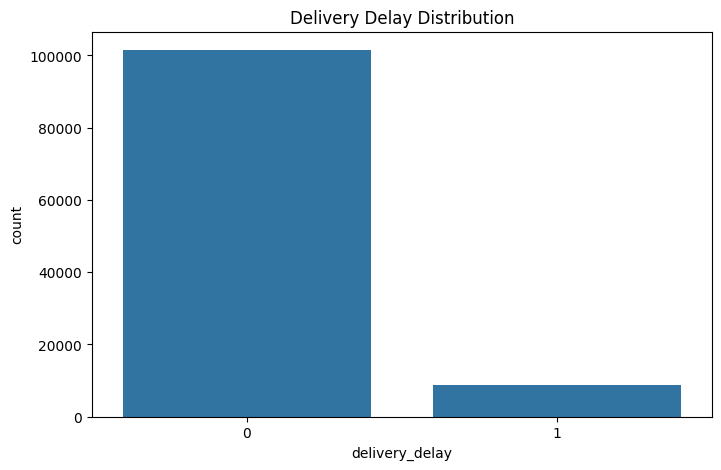

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='delivery_delay',
    data=df
)
plt.title("Delivery Delay Distribution")
plt.show()

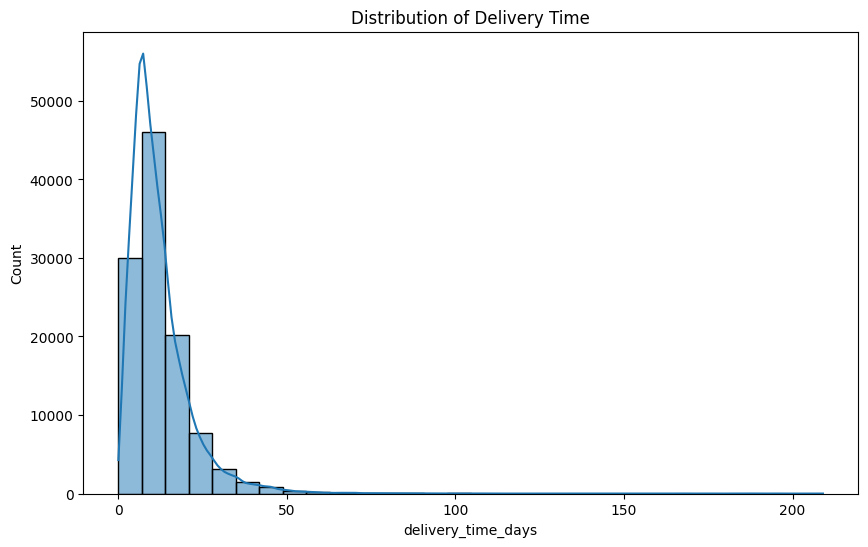

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(
    df['delivery_time_days'],
    bins=30,
    kde=True
)
plt.title("Distribution of Delivery Time")
plt.show()

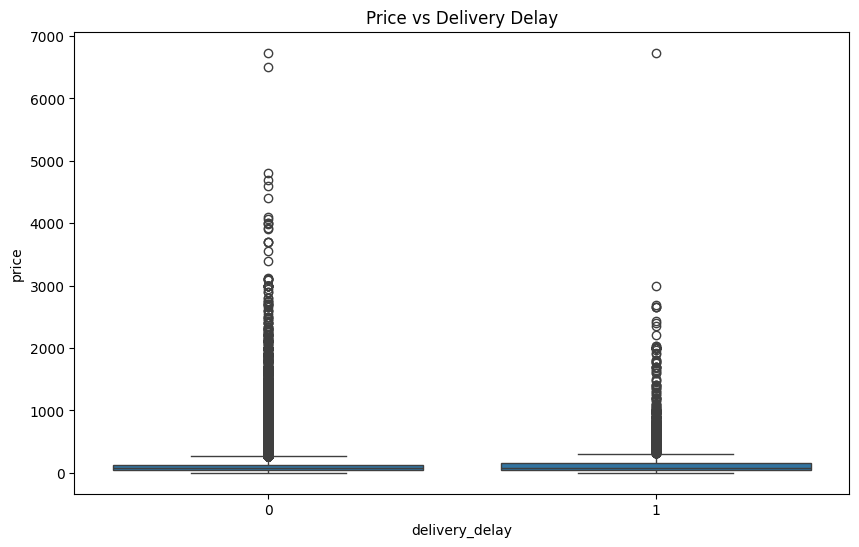

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='delivery_delay',
    y='price',
    data=df
)
plt.title("Price vs Delivery Delay")
plt.show()

###**Operational Trend Analysis**

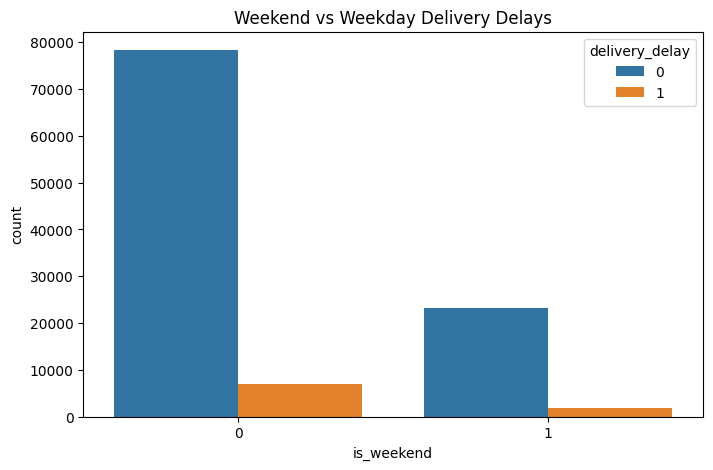

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='is_weekend',
    hue='delivery_delay',
    data=df
)
plt.title("Weekend vs Weekday Delivery Delays")
plt.show()

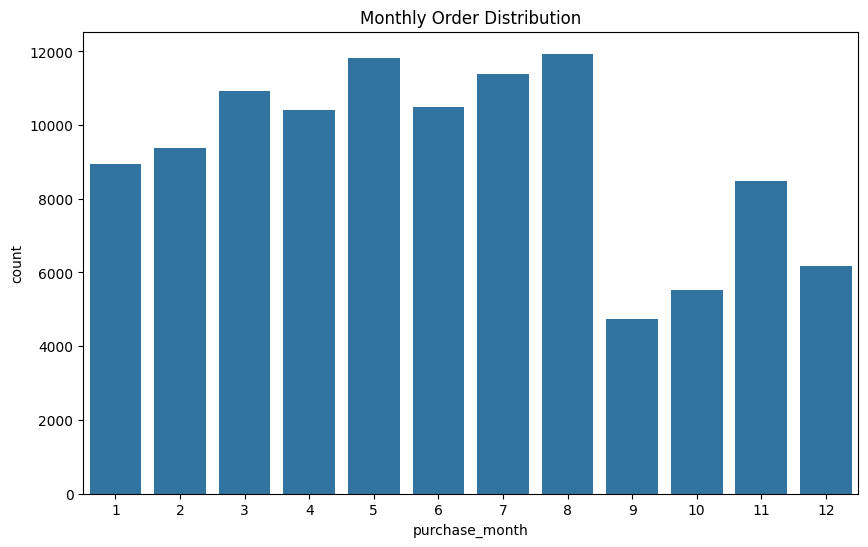

In [31]:
plt.figure(figsize=(10,6))
sns.countplot(
    x='purchase_month',
    data=df
)
plt.title("Monthly Order Distribution")
plt.show()

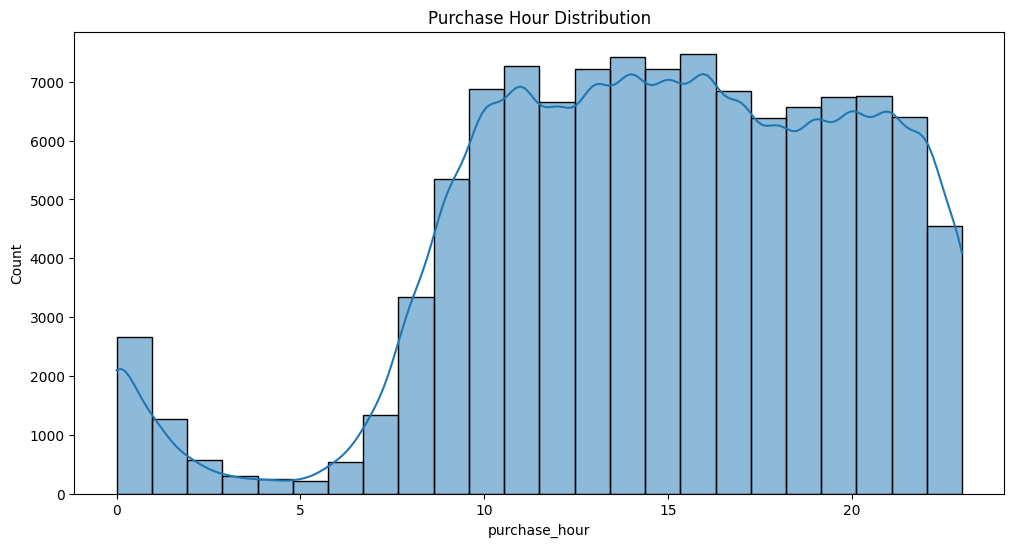

In [32]:
plt.figure(figsize=(12,6))
sns.histplot(
    df['purchase_hour'],
    bins=24,
    kde=True
)
plt.title("Purchase Hour Distribution")
plt.show()

###**Freight & Pricing Intelligence**

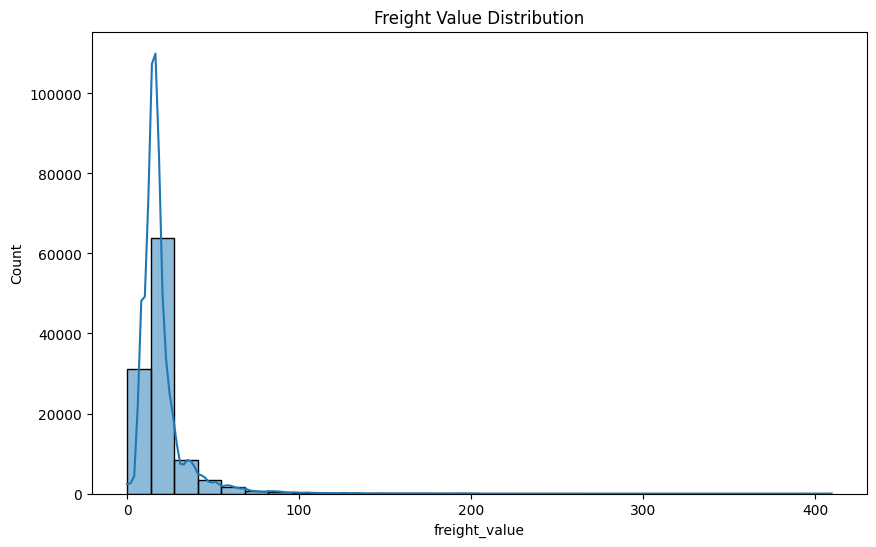

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(
    df['freight_value'],
    bins=30,
    kde=True
)
plt.title("Freight Value Distribution")
plt.show()

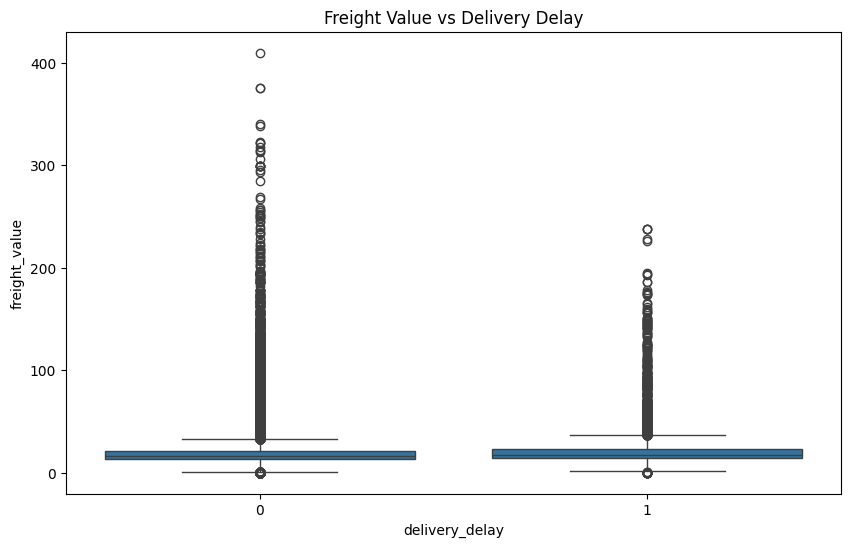

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='delivery_delay',
    y='freight_value',
    data=df
)
plt.title("Freight Value vs Delivery Delay")
plt.show()

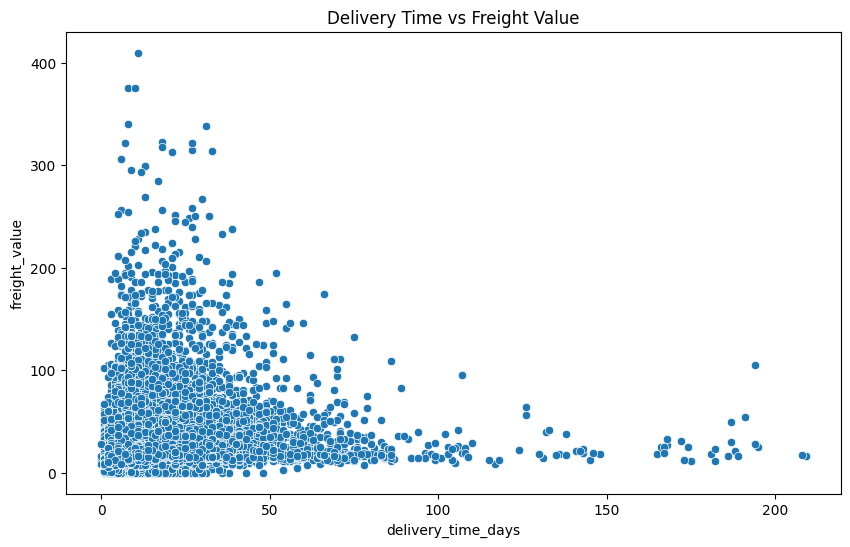

In [35]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='delivery_time_days',
    y='freight_value',
    data=df
)
plt.title("Delivery Time vs Freight Value")
plt.show()

###**Correlation & Operational Intelligence Analysis**

In [36]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

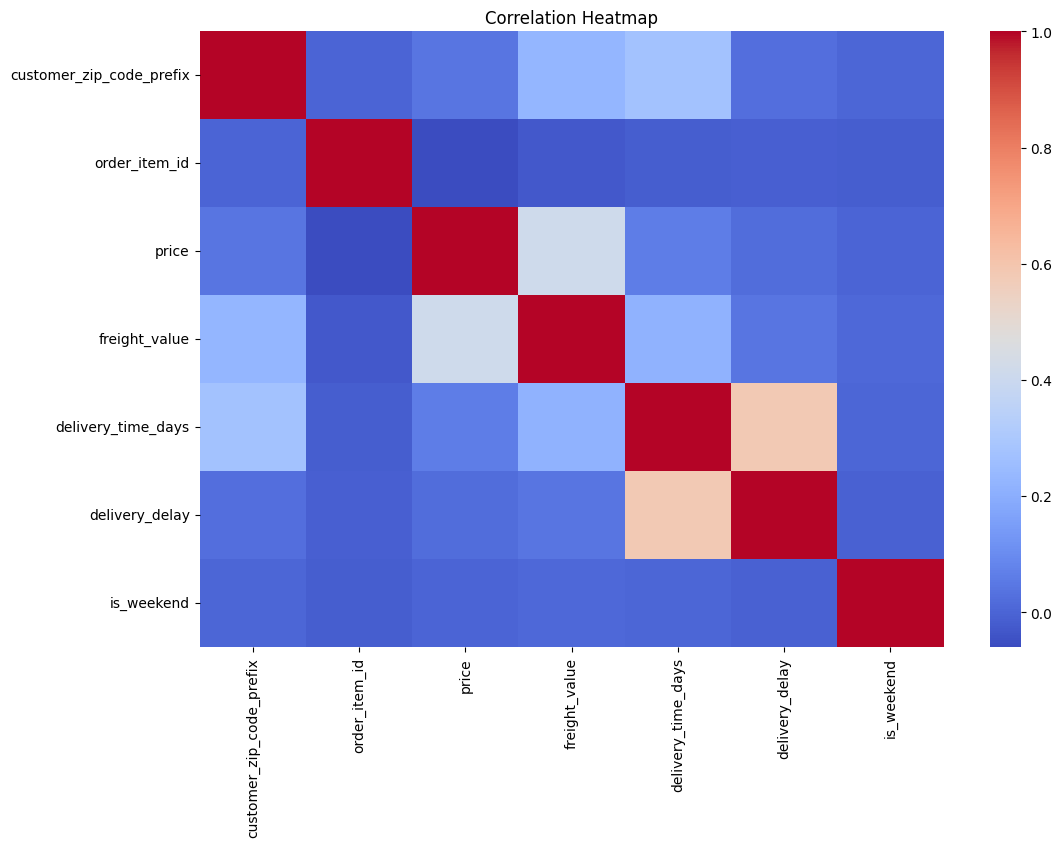

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

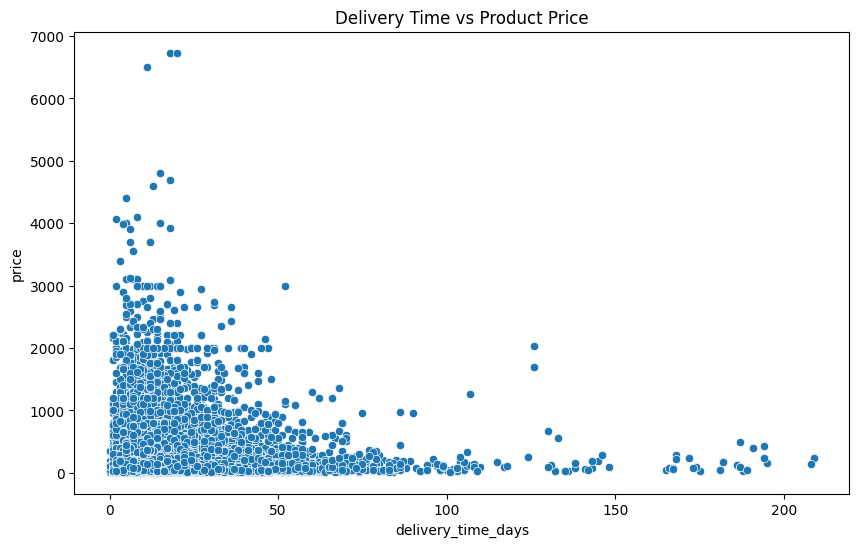

In [38]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='delivery_time_days',
    y='price',
    data=df
)
plt.title("Delivery Time vs Product Price")
plt.show()

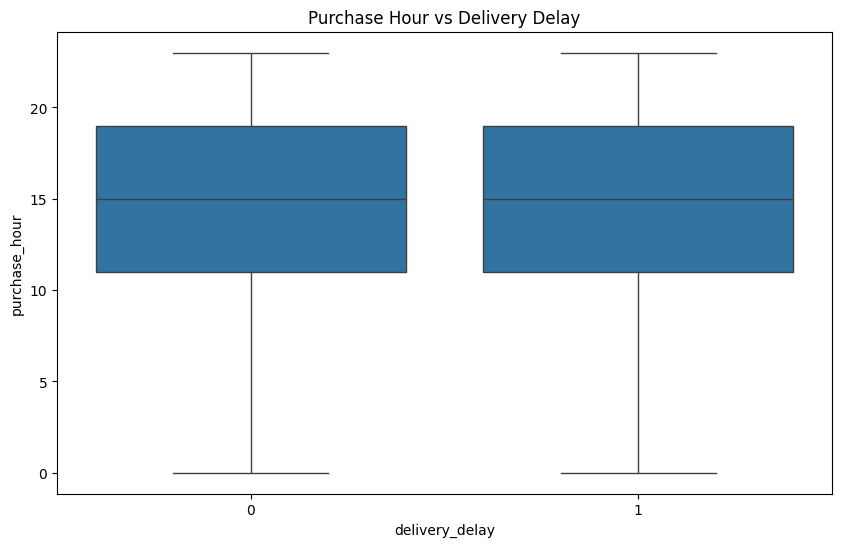

In [39]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='delivery_delay',
    y='purchase_hour',
    data=df
)
plt.title("Purchase Hour vs Delivery Delay")
plt.show()

##**Machine Learning Preparation**
**analytics to predictive intelligence**

In [40]:
features = [
    'price',
    'freight_value',
    'purchase_hour',
    'purchase_day',
    'purchase_month',
    'purchase_weekday',
    'is_weekend',
    'delivery_time_days'
]

X = df[features]
y = df['delivery_delay']

In [41]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (110196, 8)
Target Shape: (110196,)


**Preparing Training and Testing Data**

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (88156, 8)
Testing Data Shape: (22040, 8)


###**Logistic Regression Model**

In [44]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [45]:
y_pred_lr = lr_model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9501814882032668


In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     20254
           1       0.81      0.50      0.62      1786

    accuracy                           0.95     22040
   macro avg       0.88      0.75      0.80     22040
weighted avg       0.95      0.95      0.94     22040



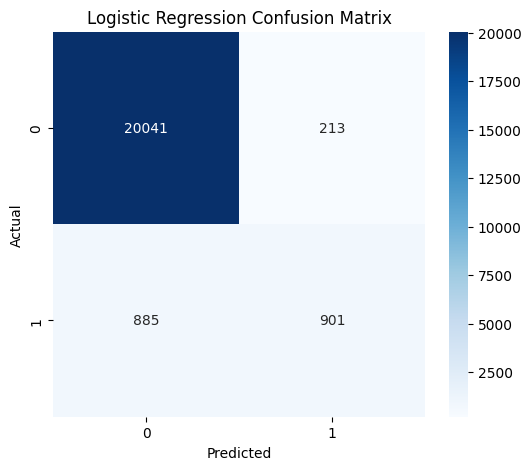

In [48]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###**Random Forest Classifier**

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [50]:
y_pred_rf = rf_model.predict(X_test)

In [51]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9639745916515426


In [52]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     20254
           1       0.85      0.67      0.75      1786

    accuracy                           0.96     22040
   macro avg       0.91      0.83      0.87     22040
weighted avg       0.96      0.96      0.96     22040



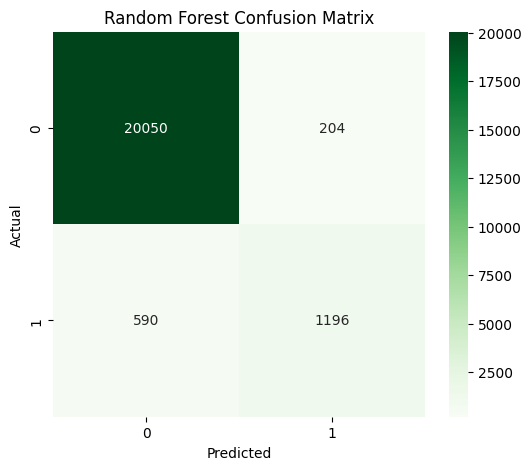

In [53]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(
    conf_matrix_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve for Random Forest**

In [54]:
from sklearn.metrics import roc_curve, auc

In [55]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [56]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

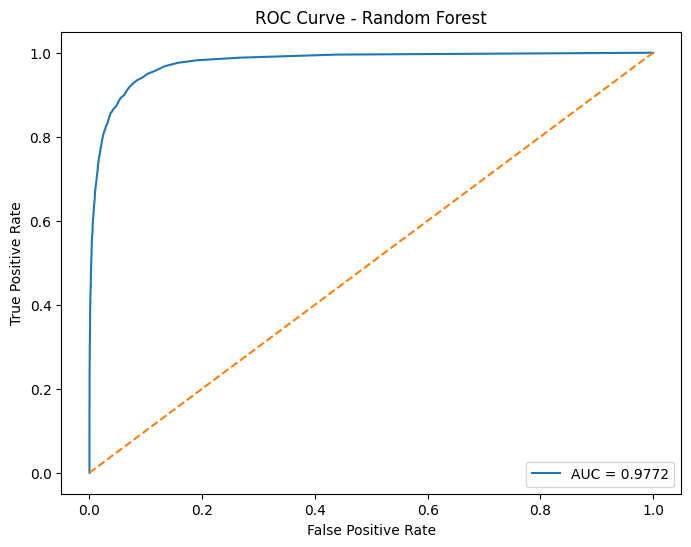

In [57]:
plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

**Random Forest Operational Insights**

In [58]:
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [59]:
feature_importance

,Feature,Importance
7,delivery_time_days,0.540544
1,freight_value,0.129739
0,price,0.105678
2,purchase_hour,0.066710
3,purchase_day,0.066006
4,purchase_month,0.056647
5,purchase_weekday,0.029997
6,is_weekend,0.004681


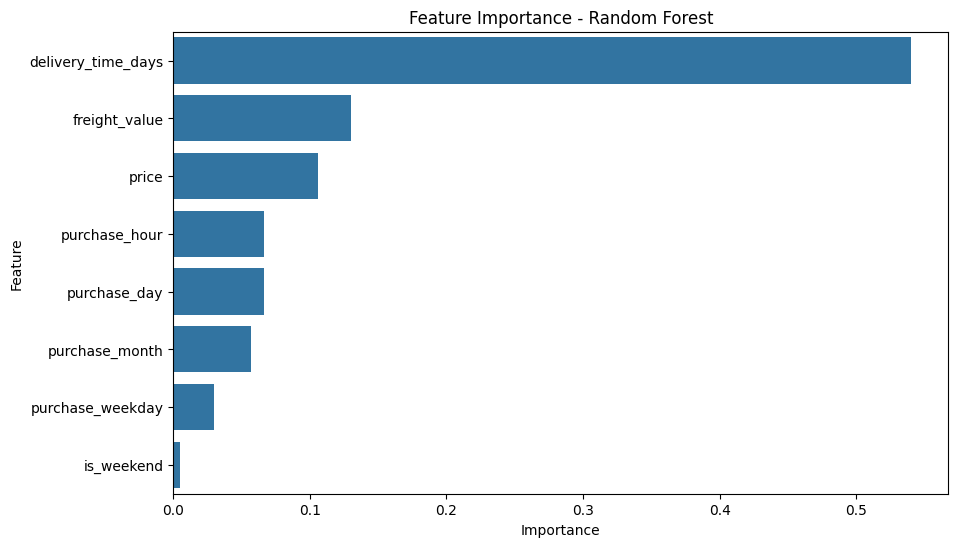

In [60]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("Feature Importance - Random Forest")
plt.show()

#**Route Optimization Engine**

In [61]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 wh

In [62]:
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

Simulated Delivery Nodes

In [63]:
locations = [
    (0, 0),
    (2, 3),
    (5, 4),
    (1, 7),
    (6, 8),
    (7, 2)
]

Import Distance Calculation Library

In [64]:
import math

Create Distance Matrix Function

In [65]:
def compute_distance_matrix(locations):
    distance_matrix = []
    for from_node in locations:
        row = []
        for to_node in locations:
            distance = math.hypot(
                from_node[0] - to_node[0],
                from_node[1] - to_node[1]
            )
            row.append(int(distance))
        distance_matrix.append(row)
    return distance_matrix

In [66]:
distance_matrix = compute_distance_matrix(locations)
distance_matrix
#travel distances between delivery locations.

[[0, 3, 6, 7, 10, 7],
 [3, 0, 3, 4, 6, 5],
 [6, 3, 0, 5, 4, 2],
 [7, 4, 5, 0, 5, 7],
 [10, 6, 4, 5, 0, 6],
 [7, 5, 2, 7, 6, 0]]

#**Vehicle Routing Optimization**

**Create Data Model**

Logistics Routing Configuration

In [67]:
def create_data_model():
    data = {}
    data['distance_matrix'] = distance_matrix
    data['num_vehicles'] = 1
    data['depot'] = 0
    return data

Routing Engine Initialization

In [68]:
data = create_data_model()
manager = pywrapcp.RoutingIndexManager(
    len(data['distance_matrix']),
    data['num_vehicles'],
    data['depot']
)
routing = pywrapcp.RoutingModel(manager)

**Create Distance Callback**

Route Cost Calculation

In [69]:
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

Distance Registration

In [70]:
transit_callback_index = routing.RegisterTransitCallback(
    distance_callback
)
routing.SetArcCostEvaluatorOfAllVehicles(
    transit_callback_index
)

**Define Search Parameters**

Route Optimization Strategy

In [71]:
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)

Optimized Route Computation

In [72]:
solution = routing.SolveWithParameters(
    search_parameters
)

Optimized Route - Best Delivery Sequence

In [73]:
if solution:
    index = routing.Start(0)
    route = []
    route_distance = 0
    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        route.append(node)
        previous_index = index
        index = solution.Value(
            routing.NextVar(index)
        )
        route_distance += routing.GetArcCostForVehicle(
            previous_index,
            index,
            0
        )
    route.append(manager.IndexToNode(index))
    print("Optimized Route:", route)
    print("Total Distance:", route_distance)

Optimized Route: [0, 1, 2, 5, 4, 3, 0]
Total Distance: 26


Delivery Locations - Route Visualization

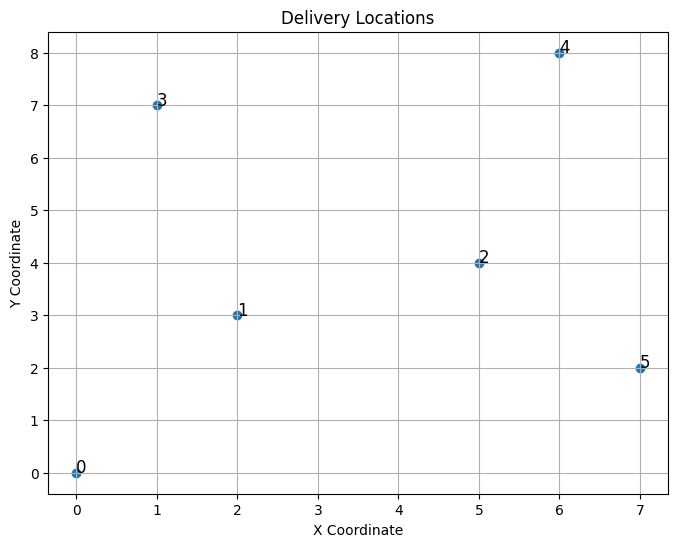

In [74]:
x = [loc[0] for loc in locations]
y = [loc[1] for loc in locations]
plt.figure(figsize=(8,6))
plt.scatter(x, y)
for i, (x_coord, y_coord) in enumerate(locations):
    plt.text(
        x_coord,
        y_coord,
        str(i),
        fontsize=12
    )
plt.title("Delivery Locations")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

Optimized Logistics Path

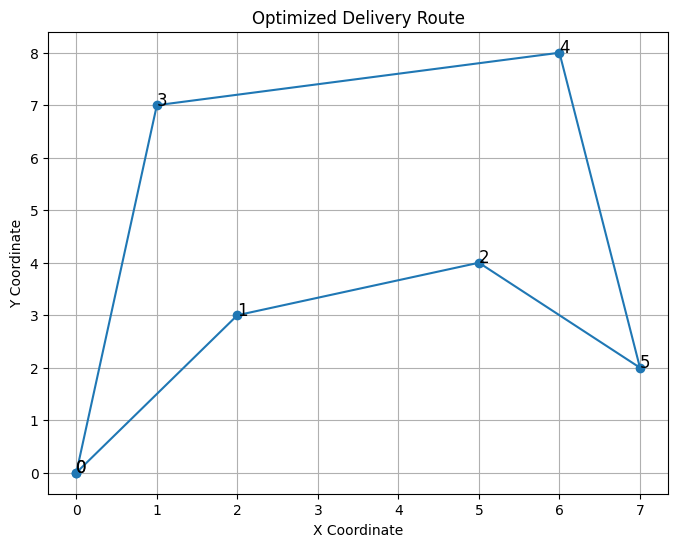

In [75]:
route_locations = [locations[node] for node in route]
x_route = [loc[0] for loc in route_locations]
y_route = [loc[1] for loc in route_locations]
plt.figure(figsize=(8,6))
plt.plot(
    x_route,
    y_route,
    marker='o'
)
for i, (x_coord, y_coord) in enumerate(route_locations):
    plt.text(
        x_coord,
        y_coord,
        str(route[i]),
        fontsize=12
    )
plt.title("Optimized Delivery Route")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

Simulated Delay Risk Weights

In [76]:
risk_scores = [0, 2, 5, 1, 4, 3]

Operational Risk Table

In [77]:
for i, score in enumerate(risk_scores):
    print(f"Location {i} → Risk Score: {score}")

Location 0 → Risk Score: 0
Location 1 → Risk Score: 2
Location 2 → Risk Score: 5
Location 3 → Risk Score: 1
Location 4 → Risk Score: 4
Location 5 → Risk Score: 3


Risk-Based Delivery Intelligence

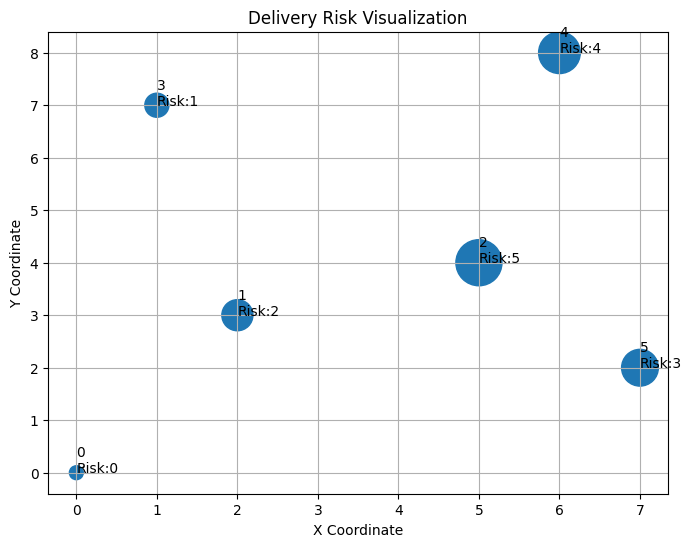

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(
    x,
    y,
    s=[score * 200 + 100 for score in risk_scores]
)
for i, (x_coord, y_coord) in enumerate(locations):
    plt.text(
        x_coord,
        y_coord,
        f"{i}\nRisk:{risk_scores[i]}",
        fontsize=10
    )
plt.title("Delivery Risk Visualization")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

##**Intelligent route prioritization**
Risk-Penalized Distance Matrix - Intelligent Routing Logic

In [79]:
risk_distance_matrix = []
for i in range(len(distance_matrix)):
    row = []
    for j in range(len(distance_matrix)):
        adjusted_distance = (
            distance_matrix[i][j]
            + risk_scores[j]
        )
        row.append(adjusted_distance)
    risk_distance_matrix.append(row)
risk_distance_matrix

[[0, 5, 11, 8, 14, 10],
 [3, 2, 8, 5, 10, 8],
 [6, 5, 5, 6, 8, 5],
 [7, 6, 10, 1, 9, 10],
 [10, 8, 9, 6, 4, 9],
 [7, 7, 7, 8, 10, 3]]

Risk-Aware Data Model

In [80]:
def create_risk_data_model():
    data = {}
    data['distance_matrix'] = risk_distance_matrix
    data['num_vehicles'] = 1
    data['depot'] = 0
    return data

Risk Routing Model

In [81]:
risk_data = create_risk_data_model()
risk_manager = pywrapcp.RoutingIndexManager(
    len(risk_data['distance_matrix']),
    risk_data['num_vehicles'],
    risk_data['depot']
)
risk_routing = pywrapcp.RoutingModel(
    risk_manager
)

Risk Distance Callback

In [82]:
def risk_distance_callback(from_index, to_index):
    from_node = risk_manager.IndexToNode(from_index)
    to_node = risk_manager.IndexToNode(to_index)
    return risk_data['distance_matrix'][from_node][to_node]

Register Risk Callback

In [83]:
risk_transit_callback_index = (
    risk_routing.RegisterTransitCallback(
        risk_distance_callback
    )
)
risk_routing.SetArcCostEvaluatorOfAllVehicles(
    risk_transit_callback_index
)

Risk Optimization Parameters - Intelligent Route Search Strategy

In [84]:
risk_search_parameters = (
    pywrapcp.DefaultRoutingSearchParameters()
)
risk_search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)

Solve Risk-Aware Routing Problem - AI-Driven Route Optimization

In [85]:
risk_solution = risk_routing.SolveWithParameters(
    risk_search_parameters
)

Extract Optimized Risk-Aware Route - Intelligent Delivery Sequence

In [86]:
if risk_solution:
    index = risk_routing.Start(0)
    risk_route = []
    risk_route_distance = 0
    while not risk_routing.IsEnd(index):
        node = risk_manager.IndexToNode(index)
        risk_route.append(node)
        previous_index = index
        index = risk_solution.Value(
            risk_routing.NextVar(index)
        )
        risk_route_distance += (
            risk_routing.GetArcCostForVehicle(
                previous_index,
                index,
                0
            )
        )
    risk_route.append(
        risk_manager.IndexToNode(index)
    )
    print("Risk-Aware Optimized Route:", risk_route)
    print(
        "Risk-Aware Total Cost:",
        risk_route_distance
    )

Risk-Aware Optimized Route: [0, 1, 3, 4, 2, 5, 0]
Risk-Aware Total Cost: 40


Visualize Intelligent Route - Risk-Aware Logistics Path

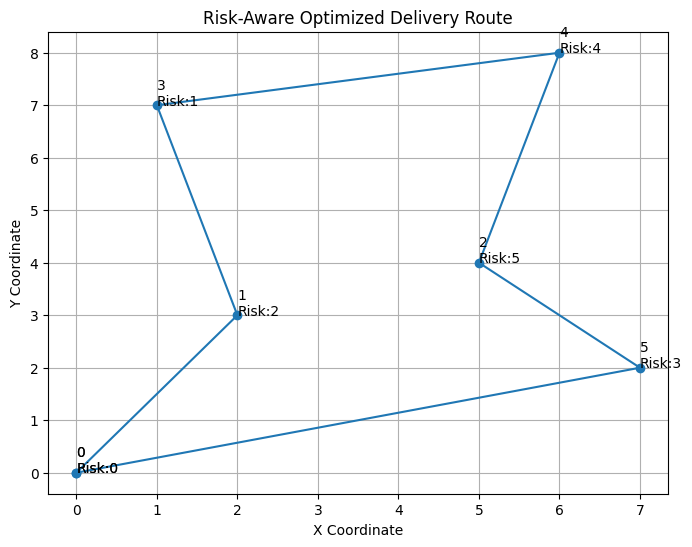

In [87]:
risk_route_locations = [
    locations[node]
    for node in risk_route
]
x_risk = [
    loc[0]
    for loc in risk_route_locations
]
y_risk = [
    loc[1]
    for loc in risk_route_locations
]
plt.figure(figsize=(8,6))
plt.plot(
    x_risk,
    y_risk,
    marker='o'
)
for i, (x_coord, y_coord) in enumerate(risk_route_locations):
    plt.text(
        x_coord,
        y_coord,
        f"{risk_route[i]}\nRisk:{risk_scores[risk_route[i]]}",
        fontsize=10
    )
plt.title("Risk-Aware Optimized Delivery Route")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

# **FastAPI Backend Development**

In [88]:
!pip install fastapi uvicorn pyngrok nest-asyncio

In [89]:
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn
import nest_asyncio
from pyngrok import ngrok

In [90]:
nest_asyncio.apply()

In [91]:
app = FastAPI()

In [92]:
@app.get("/")
def home():
    return {
        "message": "OptiRoute Logistics API Running Successfully"
    }

In [93]:
class DeliveryInput(BaseModel):
    price: float
    freight_value: float
    purchase_hour: int
    purchase_day: int
    purchase_month: int
    purchase_weekday: int
    is_weekend: int
    delivery_time_days: float

In [94]:
@app.post("/predict-delay")
def predict_delay(data: DeliveryInput):
    features = [[
        data.price,
        data.freight_value,
        data.purchase_hour,
        data.purchase_day,
        data.purchase_month,
        data.purchase_weekday,
        data.is_weekend,
        data.delivery_time_days
    ]]
    prediction = rf_model.predict(features)[0]
    probability = rf_model.predict_proba(features)[0][1]
    return {
        "delivery_delay_prediction": int(prediction),
        "delay_probability": float(probability)
    }

In [95]:
from pyngrok import ngrok
ngrok.set_auth_token("3C7u2aubV4WujtiQQ8tWhVLhNB0_3DeTdZJwiht9DtNxKYgT4")

In [96]:
public_url = ngrok.connect(8000)
print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://cleta-knotlike-eleonor.ngrok-free.dev" -> "http://localhost:8000"


In [97]:
import uvicorn
server = uvicorn.Server(
    uvicorn.Config(
        app,
        host="0.0.0.0",
        port=8000
    )
)
await server.serve()

INFO:     Started server process [5295]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     45.120.57.162:0 - "GET / HTTP/1.1" 200 OK
INFO:     45.120.57.162:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     45.120.57.162:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     45.120.57.162:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     45.120.57.162:0 - "POST /predict-delay HTTP/1.1" 200 OK
INFO:     45.120.57.162:0 - "POST /predict-delay HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [5295]


##**Key Insights**
The dataset exhibited an imbalanced delivery pattern, with the majority of deliveries completed on time and a smaller percentage experiencing delays.

Delivery duration showed a strong relationship with delayed shipments, making it the most influential operational feature.

Freight cost and product price significantly impacted delivery performance and logistics complexity.

Peak purchasing activity occurred during daytime and evening hours, indicating high operational load periods.

Monthly order analysis revealed seasonal fluctuations in e-commerce demand and shipping activity.

Random Forest outperformed Logistic Regression in predicting delayed deliveries, achieving stronger recall and ROC-AUC performance.

Feature importance analysis highlighted delivery time, freight value, and purchase timing as major drivers of operational delays.

The project successfully demonstrated how machine learning can support proactive logistics risk management and operational decision-making.

##**Conclusion**:
This project successfully developed an AI-driven logistics intelligence system for analyzing and predicting e-commerce delivery delays using real-world operational data. Through data engineering, feature extraction, exploratory analysis, and predictive modeling, the system identified critical logistics patterns and operational factors influencing shipment performance.

The Random Forest model achieved strong predictive performance and demonstrated the effectiveness of machine learning in logistics risk prediction and delivery intelligence systems. Additionally, the project provided valuable business insights related to freight cost, delivery duration, customer ordering behavior, and operational efficiency.

Overall, the project highlights the practical application of Data Science, Machine Learning, and Business Analytics in modern supply chain and logistics operations. The developed pipeline also establishes a strong foundation for future enhancements such as route optimization, real-time delivery monitoring, FastAPI integration, and deployment-ready logistics intelligence platforms.

##**Future Improvements**

* Integrate Google OR-Tools for dynamic route and fleet optimization
* Incorporate real-time traffic and weather APIs for live delivery risk prediction
* Build an interactive Streamlit dashboard for operational monitoring and analytics
* Deploy the prediction system using FastAPI and Docker containers
* Implement advanced machine learning models such as XGBoost or LightGBM
* Add geospatial analysis and route visualization using mapping libraries
* Develop real-time delivery tracking and alert systems
* Optimize delivery scheduling based on operational constraints and customer time windows
* Perform hyperparameter tuning to further improve model performance
* Extend the system into a scalable end-to-end logistics intelligence platform for enterprise applications
